# DS-Wave non-adaptive testing

Standalone DS-Wave target solving and toroidal point synthesis.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # For Windows

import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [2]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np

import plotly.graph_objects as go
import nbformat
print(nbformat.__version__)
print(nbformat.__file__)

module_path = Path("ds-wave.py").resolve()
if not module_path.exists():
	module_path = Path("python") / "ds-wave.py"
module_path = module_path.resolve()
spec = importlib.util.spec_from_file_location("ds_wave", module_path)
ds_wave = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ds_wave)

python_dir = Path("python").resolve()
if python_dir.exists() and str(python_dir) not in sys.path:
	sys.path.insert(0, str(python_dir))
import ds_wave_3D as ds_wave_3d

plt.rcParams["figure.dpi"] = 120


def make_low_bands(max_nu):
	return [
		(low, min(high, max_nu))
		for low, high in [(0.0, 0.5), (0.5, 0.6), (0.6, 0.67), (0.67, max_nu)]
		if min(high, max_nu) > low
	]


def describe_target(label, target):
	print(f"{label}: status={target['status']}, m0={target.get('m0')}")
	if target["success"]:
		print(f"{label} r range: 0 <= r <= {target['r'][-1]:.6f}, samples={len(target['r'])}")
	else:
		print(target["message"])


def print_target_mode_summary(label, target, max_nu, n_points, bands):
	print(f"\n{label}")
	if not target["success"]:
		print(target["message"])
		return None
	report = ds_wave.compute_target_mode_powers(
		target,
		n_points=n_points,
		nu_max=max_nu,
		mode_limit=0,
	)
	print_mode_report(report, bands)
	return report


def print_mode_report(report, bands=None, top_count=0):
	print(f"mode count: {report['mode_count']}")
	print(f"mean power:   {report['mean_power']:.10f}")
	print(f"median power: {report['median_power']:.10f}")
	print(f"max power:    {report['max_power']:.10f}")
	if bands is not None:
		for summary in ds_wave.summarise_mode_power_bands(report, bands):
			lo, hi = summary["range"]
			print(
				f"{lo:.3f} <= nu < {hi:.3f}: "
				f"count={summary['count']}, "
				f"mean={summary['mean_power']:.10f}, "
				f"median={summary['median_power']:.10f}, "
				f"max={summary['max_power']:.10f}"
			)
	if top_count > 0:
		print("Top low-frequency modes:")
		for mode, radius, power in zip(report["modes"][:top_count], report["radii"][:top_count], report["powers"][:top_count]):
			print(f"k={mode.astype(int)}, nu={radius:.6f}, power={power:.6f}")


def print_point_mode_summary(label, point_set, max_nu, bands=None, mode_limit=0, top_count=0):
	print(f"\n{label}")
	report = ds_wave.compute_low_frequency_mode_powers(
		point_set,
		nu_max=max_nu,
		mode_limit=mode_limit,
	)
	print_mode_report(report, bands=bands, top_count=top_count)
	return report


def set_active_points(point_set, label):
	global points, active_points_label
	points = point_set
	active_points_label = label
	print(f"Active point set: {active_points_label}")


5.10.4
c:\Users\ville\anaconda3\envs\bluenoise_pointprocesses\Lib\site-packages\nbformat\__init__.py


In [3]:
# Easy-to-edit parameters
nu0 = 0.85
#nu0 = 0.70
e0 = 0.0
nu_max = 10.0
n_nu = 1001
n_r = 128
n_points = 2048
iterations = 1000
seed = 1234
m0_values = [1.0, 2.0, "min"]
device = "auto"
spectrum_learning_rate = 0.03
mode_limit = 12000
mode_chunk_size = 512
low_frequency_weight = 50.0

# Options: ds_wave.SynthesisMode.SPECTRUM_MATCHING or ds_wave.SynthesisMode.PCF_MATCHING
synthesis_mode = ds_wave.SynthesisMode.PCF_MATCHING
pcf_step_scale = 1.0
pcf_num_bins = None  # None uses n_points, matching targetrdf
pcf_smoothing = 8.0  # RDF Gaussian smoothing in bins, matching targetrdf default
pcf_chunk_size = 256
initial_points = None

# Notebook execution policy: cells run top-to-bottom.
# Keep raw TargetRDF as the default DS-Wave output; refinement is a separate diagnostic.
use_low_frequency_refined_points_for_plots = False
low_frequency_refine_iterations = 250
low_frequency_refine_learning_rate = 0.01
low_frequency_refine_nu = None  # None uses nu0
low_frequency_refine_mode_limit = 0  # 0 keeps all low modes
low_frequency_refine_mode_chunk_size = 512

# Extra diagnostics. These do not replace the active 2D point set used by the periodogram.
sweep_iterations = min(iterations, 1000)
sweep_include_full_domain_target = True
sweep_pcf_smoothing_values = [max(0.0, 0.5 * pcf_smoothing), pcf_smoothing, 1.5 * pcf_smoothing]
sweep_pcf_num_bins_values = [128, 256, 512]
sweep_pcf_step_scale_values = [0.5 * pcf_step_scale, pcf_step_scale, 1.5 * pcf_step_scale]

n_points_3d = 4096
iterations_3d = 5 * iterations
pcf_num_bins_3d = pcf_num_bins
pcf_smoothing_3d = pcf_smoothing
pcf_step_scale_3d = pcf_step_scale
pcf_chunk_size_3d = pcf_chunk_size


m0=1.0: infeasible - The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
m0=2.0: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)
m0=min: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)


C:\Users\ville\AppData\Local\Temp\ipykernel_115124\2157386874.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


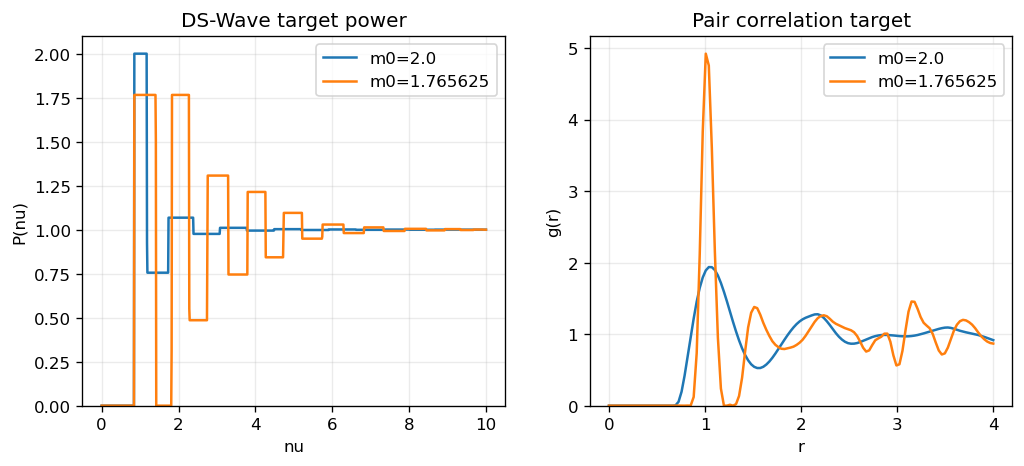

In [4]:
targets = {}
for m0 in m0_values:
	target = ds_wave.solve_ds_wave_target(
		nu0=nu0,
		e0=e0,
		m0=m0,
		nu_max=nu_max,
		n_nu=n_nu,
		n_r=n_r,
		require_success=False,
	)
	targets[str(m0)] = target
	print(f"m0={m0}: {target['status']} - {target['message']}")

fig = ds_wave.plot_ds_wave_targets(list(targets.values()))
fig.show()

In [5]:
# Compare the existing r_max target against the full TargetRDF-domain target.
min_target = targets["min"]
full_domain_target = ds_wave.solve_ds_wave_target_for_targetrdf(
	n_points=n_points,
	nu0=nu0,
	e0=e0,
	m0="min",
	nu_max=nu_max,
	n_nu=n_nu,
	require_success=False,
)

target_low_bands = make_low_bands(nu0)
for label, target in [("current target", min_target), ("full-domain target", full_domain_target)]:
	describe_target(label, target)

for label, target in [("current r_max target", min_target), ("full TargetRDF-domain target", full_domain_target)]:
	print_target_mode_summary(label, target, nu0, n_points, target_low_bands)


current target: status=optimal, m0=1.765625
current target r range: 0 <= r <= 4.000000, samples=128
full-domain target: status=optimal, m0=1.765625
full-domain target r range: 0 <= r <= 22.627417, samples=725

current r_max target
mode count: 4644
mean power:   0.0000000000
median power: 0.0000000000
max power:    0.0000000000
0.000 <= nu < 0.500: count=1604, mean=0.0000000000, median=0.0000000000, max=0.0000000000
0.500 <= nu < 0.600: count=708, mean=0.0000000000, median=0.0000000000, max=0.0000000000
0.600 <= nu < 0.670: count=572, mean=0.0000000000, median=0.0000000000, max=0.0000000000
0.670 <= nu < 0.850: count=1760, mean=0.0000000000, median=0.0000000000, max=0.0000000000

full TargetRDF-domain target
mode count: 4644
mean power:   0.0000000000
median power: 0.0000000000
max power:    0.0000000000
0.000 <= nu < 0.500: count=1604, mean=0.0000000000, median=0.0000000000, max=0.0000000000
0.500 <= nu < 0.600: count=708, mean=0.0000000000, median=0.0000000000, max=0.0000000000
0.600 

In [6]:
min_target = targets["min"]
if not min_target["success"]:
	raise RuntimeError(min_target["message"])

raw_synthesis = ds_wave.synthesize_toroidal_points(
	min_target,
	n_points=n_points,
	iterations=iterations,
	seed=seed,
	device=device,
	spectrum_learning_rate=spectrum_learning_rate,
	mode_limit=mode_limit,
	mode_chunk_size=mode_chunk_size,
	low_frequency_weight=low_frequency_weight,
	synthesis_mode=synthesis_mode,
	pcf_step_scale=pcf_step_scale,
	pcf_num_bins=pcf_num_bins,
	pcf_smoothing=pcf_smoothing,
	pcf_chunk_size=pcf_chunk_size,
	initial_points=initial_points,
	log_every=max(100, 1),
)
raw_points = raw_synthesis["points"]
set_active_points(raw_points, "raw PCF points")
print(f"mode={raw_synthesis['synthesis_mode']}, device={raw_synthesis['device']}, final energy={raw_synthesis['energy_history'][-1]:.6g}")
print(raw_points.shape, raw_points.min(), raw_points.max())
print(raw_synthesis.get("iterations_run", raw_synthesis.get("iterations", "iterations_run unavailable")))
print(len(raw_synthesis["energy_history"]))
print("Energy history:")
for value in raw_synthesis["energy_history"][-10:]:
	print(value)


Active point set: raw PCF points
mode=pcf_matching, device=cuda, final energy=0.0219866
(2048, 2) 0.0001793654 0.99895227
1000
11
Energy history:
0.04304295253352637
0.022471352189980556
0.022012524180469204
0.021986608525116153
0.021986608525116153
0.021986608525116153
0.021986608525116153
0.021986608525116153
0.021986608525116153
0.021986608525116153


In [7]:
# Low-frequency cleanup diagnostic for 2D points.
# This is useful for inspecting the forbidden disk, but it is not the faithful DS-Wave TargetRDF result.
refinement_nu = nu0 if low_frequency_refine_nu is None else low_frequency_refine_nu
low_bands = make_low_bands(refinement_nu)

before_low_report = print_point_mode_summary(
	"raw TargetRDF before refinement",
	raw_points,
	refinement_nu,
	bands=low_bands,
	mode_limit=low_frequency_refine_mode_limit,
)

low_frequency_refinement = ds_wave.synthesize_toroidal_points(
	min_target,
	n_points=raw_points.shape[0],
	seed=seed,
	device=device,
	synthesis_mode=ds_wave.SynthesisMode.LOW_FREQUENCY_REFINE,
	initial_points=raw_points,
	low_frequency_refine_iterations=low_frequency_refine_iterations,
	low_frequency_refine_learning_rate=low_frequency_refine_learning_rate,
	low_frequency_refine_nu=low_frequency_refine_nu,
	low_frequency_refine_mode_limit=low_frequency_refine_mode_limit,
	low_frequency_refine_mode_chunk_size=low_frequency_refine_mode_chunk_size,
	log_every=max(low_frequency_refine_iterations // 5, 1),
)
low_frequency_refined_points = low_frequency_refinement["points"]
after_low_report = print_point_mode_summary(
	"low-frequency refined diagnostic",
	low_frequency_refined_points,
	refinement_nu,
	bands=low_bands,
	mode_limit=low_frequency_refine_mode_limit,
)

print("Refinement energy history:")
for value in low_frequency_refinement["energy_history"]:
	print(value)

if use_low_frequency_refined_points_for_plots:
	set_active_points(low_frequency_refined_points, "low-frequency refined diagnostic points")
else:
	set_active_points(raw_points, "raw TargetRDF PCF points")



raw TargetRDF before refinement
mode count: 4644
mean power:   0.0766235107
median power: 0.0370805758
max power:    1.9160188004
0.000 <= nu < 0.500: count=1604, mean=0.0271441005, median=0.0146104919, max=0.3040724431
0.500 <= nu < 0.600: count=708, mean=0.0479782728, median=0.0346571758, max=0.2549438984
0.600 <= nu < 0.670: count=572, mean=0.0540577866, median=0.0409191241, max=0.3197066168
0.670 <= nu < 0.850: count=1760, mean=0.1405743043, median=0.0784488975, max=1.9160188004

low-frequency refined diagnostic
mode count: 4644
mean power:   0.0004759854
median power: 0.0002420373
max power:    0.0076442619
0.000 <= nu < 0.500: count=1604, mean=0.0007948261, median=0.0005502635, max=0.0076442619
0.500 <= nu < 0.600: count=708, mean=0.0006446692, median=0.0003915375, max=0.0036877065
0.600 <= nu < 0.670: count=572, mean=0.0003790530, median=0.0002896579, max=0.0029188855
0.670 <= nu < 0.850: count=1760, mean=0.0001490517, median=0.0000853221, max=0.0018446162
Refinement energy his

In [8]:
# PCF synthesis comparison for the full TargetRDF-domain target.
if not full_domain_target["success"]:
	raise RuntimeError(full_domain_target["message"])

full_domain_synthesis = ds_wave.synthesize_toroidal_points(
	full_domain_target,
	n_points=n_points,
	iterations=iterations,
	seed=seed,
	device=device,
	synthesis_mode=ds_wave.SynthesisMode.PCF_MATCHING,
	pcf_step_scale=pcf_step_scale,
	pcf_num_bins=pcf_num_bins,
	pcf_smoothing=pcf_smoothing,
	pcf_chunk_size=pcf_chunk_size,
	initial_points=initial_points,
	log_every=max(100, 1),
)
full_domain_points = full_domain_synthesis["points"]
print(
	f"full-domain mode={full_domain_synthesis['synthesis_mode']}, "
	f"device={full_domain_synthesis['device']}, "
	f"final energy={full_domain_synthesis['energy_history'][-1]:.6g}"
)
print(full_domain_points.shape, full_domain_points.min(), full_domain_points.max())

comparison_low_bands = make_low_bands(nu0)
comparison_sets = [
	("raw TargetRDF points", raw_points),
]
if low_frequency_refined_points is not None:
	comparison_sets.append(("low-frequency cleanup points", low_frequency_refined_points))
comparison_sets.append(("active plotted points", points))
comparison_sets.append(("full TargetRDF-domain points", full_domain_points))

seen = set()
for label, compare_points in comparison_sets:
	object_id = id(compare_points)
	if object_id in seen:
		print(f"\n{label}: same array as an earlier row; skipped duplicate.")
		continue
	seen.add(object_id)
	print_point_mode_summary(label, compare_points, nu0, bands=comparison_low_bands)


full-domain mode=pcf_matching, device=cuda, final energy=0.0218621
(2048, 2) 0.00024680872 0.9998879

raw TargetRDF points
mode count: 4644
mean power:   0.0766235107
median power: 0.0370805758
max power:    1.9160188004
0.000 <= nu < 0.500: count=1604, mean=0.0271441005, median=0.0146104919, max=0.3040724431
0.500 <= nu < 0.600: count=708, mean=0.0479782728, median=0.0346571758, max=0.2549438984
0.600 <= nu < 0.670: count=572, mean=0.0540577866, median=0.0409191241, max=0.3197066168
0.670 <= nu < 0.850: count=1760, mean=0.1405743043, median=0.0784488975, max=1.9160188004

low-frequency cleanup points
mode count: 4644
mean power:   0.0004759854
median power: 0.0002420373
max power:    0.0076442619
0.000 <= nu < 0.500: count=1604, mean=0.0007948261, median=0.0005502635, max=0.0076442619
0.500 <= nu < 0.600: count=708, mean=0.0006446692, median=0.0003915375, max=0.0036877065
0.600 <= nu < 0.670: count=572, mean=0.0003790530, median=0.0002896579, max=0.0029188855
0.670 <= nu < 0.850: coun

C:\Users\ville\AppData\Local\Temp\ipykernel_115124\863102607.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


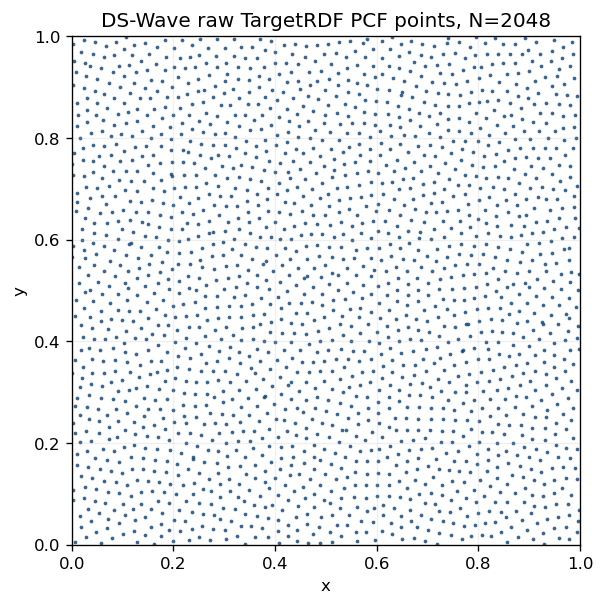

In [9]:
fig = ds_wave.plot_points(points, title=f"DS-Wave {active_points_label}, N={points.shape[0]}")
fig.show()


C:\Users\ville\AppData\Local\Temp\ipykernel_115124\2259755339.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


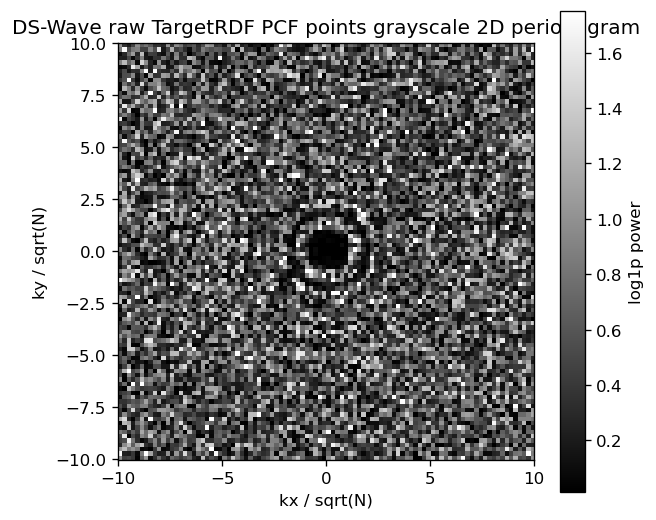

In [10]:
power_2d, extent = ds_wave.compute_periodogram_2d(points, grid_size=96, max_freq=nu_max)
fig = ds_wave.plot_periodogram(power_2d, extent, title=f"DS-Wave {active_points_label} grayscale 2D periodogram")
fig.show()


active point set: raw TargetRDF PCF points
low-frequency grid: k_max=68, grid_size=137


C:\Users\ville\AppData\Local\Temp\ipykernel_115124\842693837.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


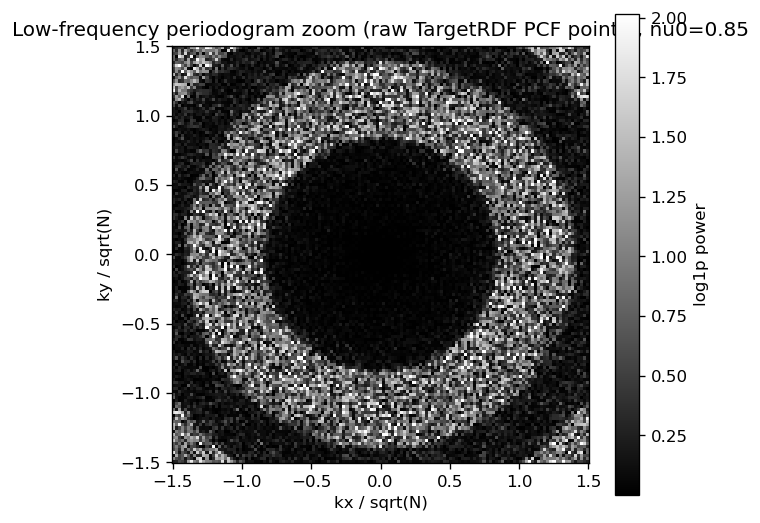

In [11]:
# Low-frequency periodogram zoom for the forbidden disk.
# This uses a contiguous integer-mode grid instead of the sparse wide-range display.
low_periodogram_max_freq = max(1.5, 1.5 * nu0)
low_k_max = int(np.ceil(low_periodogram_max_freq * np.sqrt(float(points.shape[0]))))
low_grid_size = 2 * low_k_max + 1
print(f"active point set: {active_points_label}")
print(f"low-frequency grid: k_max={low_k_max}, grid_size={low_grid_size}")

low_power_2d, low_extent = ds_wave.compute_periodogram_2d(
	points,
	grid_size=low_grid_size,
	max_freq=low_periodogram_max_freq,
)
fig = ds_wave.plot_periodogram(
	low_power_2d,
	low_extent,
	title=f"Low-frequency periodogram zoom ({active_points_label}), nu0={nu0}",
)
fig.show()


active point set: raw TargetRDF PCF points

active point set low-frequency powers
mode count: 4644
mean power:   0.0766235107
median power: 0.0370805758
max power:    1.9160188004
0.000 <= nu < 0.500: count=1604, mean=0.0271441005, median=0.0146104919, max=0.3040724431
0.500 <= nu < 0.600: count=708, mean=0.0479782728, median=0.0346571758, max=0.2549438984
0.600 <= nu < 0.670: count=572, mean=0.0540577866, median=0.0409191241, max=0.3197066168
0.670 <= nu < 0.850: count=1760, mean=0.1405743043, median=0.0784488975, max=1.9160188004
Top low-frequency modes:
k=[-36 -13], nu=0.845773, power=1.916019
k=[36 13], nu=0.845773, power=1.916019
k=[-38   5], nu=0.846927, power=1.713719
k=[38 -5], nu=0.846927, power=1.713719
k=[ 5 38], nu=0.846927, power=1.666044
k=[ -5 -38], nu=0.846927, power=1.666044
k=[-25  29], nu=0.846062, power=1.565999
k=[ 25 -29], nu=0.846062, power=1.565999
k=[-1 38], nu=0.839980, power=1.528497
k=[  1 -38], nu=0.839980, power=1.528497
k=[ 17 -34], nu=0.839980, power=1.0

C:\Users\ville\AppData\Local\Temp\ipykernel_115124\3033107872.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


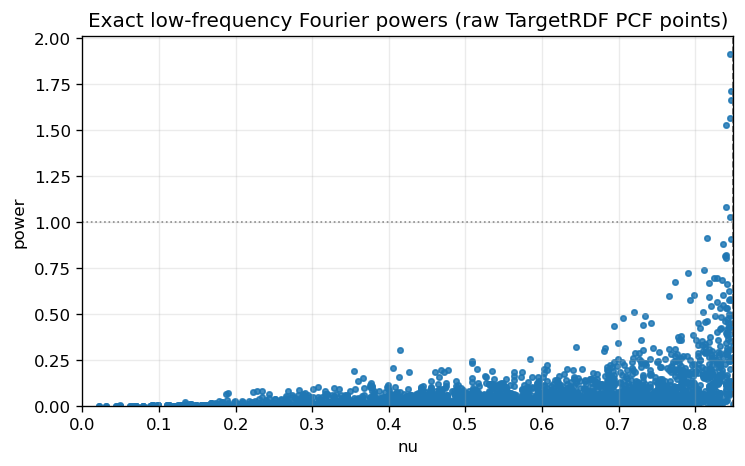

In [12]:
# Exact low-frequency mode report for nu < nu0.
print(f"active point set: {active_points_label}")
low_bands = make_low_bands(nu0)
low_report = print_point_mode_summary(
	"active point set low-frequency powers",
	points,
	nu0,
	bands=low_bands,
	top_count=20,
)

fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.scatter(low_report["radii"], low_report["powers"], s=10, alpha=0.6)
ax.axvline(nu0, color="0.4", linestyle="--", linewidth=1)
ax.axhline(1.0, color="0.55", linestyle=":", linewidth=1)
ax.set_title(f"Exact low-frequency Fourier powers ({active_points_label})")
ax.set_xlabel("nu")
ax.set_ylabel("power")
ax.set_xlim(0.0, nu0)
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.25)
fig.show()


C:\Users\ville\AppData\Local\Temp\ipykernel_115124\1249334245.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


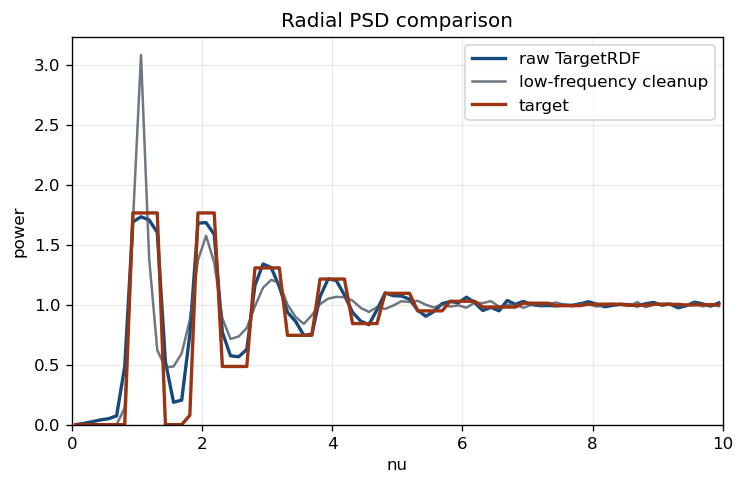

In [13]:
# Radial PSD: faithful raw TargetRDF result, with the low-frequency cleanup shown separately.
freqs, raw_radial = ds_wave.compute_radial_psd(
	raw_points,
	num_bins=80,
	max_freq=nu_max,
	mode_limit=0,
	priority_nu=min_target.get("nu0"),
)
target_power = ds_wave.interpolate_target_power(min_target, freqs)
fig, ax = plt.subplots(figsize=(7.0, 4.2), dpi=120)
ax.plot(freqs, raw_radial, label="raw TargetRDF", color="#174a7c", linewidth=2.0)
if "low_frequency_refined_points" in globals() and low_frequency_refined_points is not None:
	_, refined_radial = ds_wave.compute_radial_psd(
		low_frequency_refined_points,
		num_bins=80,
		max_freq=nu_max,
		mode_limit=0,
		priority_nu=min_target.get("nu0"),
	)
	ax.plot(freqs, refined_radial, label="low-frequency cleanup", color="#4b5563", linewidth=1.5, alpha=0.8)
ax.plot(freqs, target_power, label="target", color="#9a3412", linewidth=2.0)
ax.set_title("Radial PSD comparison")
ax.set_xlabel("nu")
ax.set_ylabel("power")
ax.set_xlim(0.0, nu_max)
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.25)
ax.legend()
fig.show()


C:\Users\ville\AppData\Local\Temp\ipykernel_115124\2644549640.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


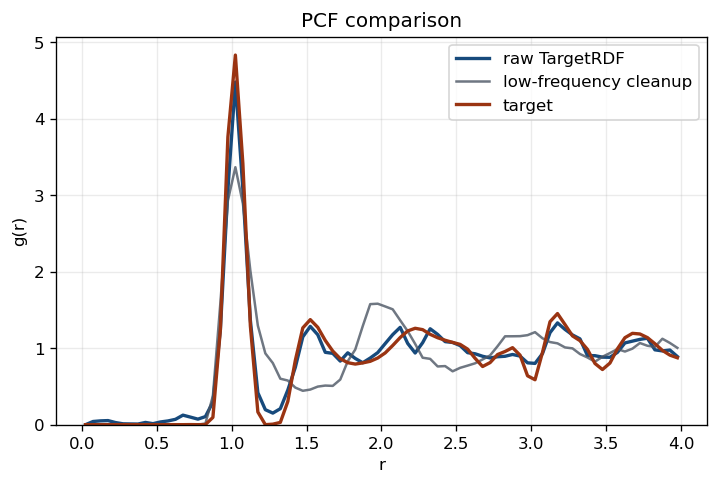

In [14]:
# PCF: faithful raw TargetRDF result, with the low-frequency cleanup shown separately.
fig, ax = plt.subplots(figsize=(7.0, 4.2), dpi=120)
for point_set, label, color, linewidth, alpha in [
	(raw_points, "raw TargetRDF", "#174a7c", 2.0, 1.0),
	((low_frequency_refined_points if "low_frequency_refined_points" in globals() else None), "low-frequency cleanup", "#4b5563", 1.5, 0.8),
]:
	if point_set is None:
		continue
	r, empirical = ds_wave.compute_empirical_pcf(point_set, r_max=float(min_target["r"][-1]))
	ax.plot(r, empirical, label=label, color=color, linewidth=linewidth, alpha=alpha)
target_g = np.interp(r, min_target["r"], min_target["g"], left=min_target["g"][0], right=min_target["g"][-1])
ax.plot(r, target_g, label="target", color="#9a3412", linewidth=2.0)
ax.set_title("PCF comparison")
ax.set_xlabel("r")
ax.set_ylabel("g(r)")
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.25)
ax.legend()
fig.show()


In [15]:
# 2D PCF parameter sweep diagnostics. This does not change the active plotted point set.
parameter_sweep_results = []
sweep_targets = [("current target", min_target)]
if sweep_include_full_domain_target:
	sweep_targets.append(("full-domain target", full_domain_target))

sweep_parameter_sets = [
	("pcf_smoothing", sweep_pcf_smoothing_values),
	("pcf_num_bins", sweep_pcf_num_bins_values),
	("pcf_step_scale", sweep_pcf_step_scale_values),
]
sweep_low_bands = make_low_bands(nu0)

for target_name, target in sweep_targets:
	if target is None or not target["success"]:
		print(f"Skipping {target_name}: target is unavailable or did not solve successfully.")
		continue

	for parameter_name, parameter_values in sweep_parameter_sets:
		for parameter_value in parameter_values:
			sweep_pcf_smoothing = pcf_smoothing
			sweep_pcf_num_bins = pcf_num_bins
			sweep_pcf_step_scale = pcf_step_scale

			if parameter_name == "pcf_smoothing":
				sweep_pcf_smoothing = parameter_value
			elif parameter_name == "pcf_num_bins":
				sweep_pcf_num_bins = parameter_value
			elif parameter_name == "pcf_step_scale":
				sweep_pcf_step_scale = parameter_value

			print(f"Running sweep: target={target_name}, {parameter_name}={parameter_value}")
			sweep_result = ds_wave.synthesize_toroidal_points(
				target,
				n_points=n_points,
				iterations=sweep_iterations,
				seed=seed,
				device=device,
				synthesis_mode=ds_wave.SynthesisMode.PCF_MATCHING,
				pcf_step_scale=sweep_pcf_step_scale,
				pcf_num_bins=sweep_pcf_num_bins,
				pcf_smoothing=sweep_pcf_smoothing,
				pcf_chunk_size=pcf_chunk_size,
				initial_points=initial_points,
				log_every=max(sweep_iterations, 1),
			)
			sweep_points = sweep_result["points"]
			sweep_report = ds_wave.compute_low_frequency_mode_powers(
				sweep_points,
				nu_max=nu0,
				mode_limit=0,
			)
			parameter_sweep_results.append({
				"target_name": target_name,
				"parameter_name": parameter_name,
				"parameter_value": parameter_value,
				"final_energy": float(sweep_result["energy_history"][-1]),
				"mean_power": sweep_report["mean_power"],
				"median_power": sweep_report["median_power"],
				"max_power": sweep_report["max_power"],
				"band_summaries": ds_wave.summarise_mode_power_bands(sweep_report, sweep_low_bands),
				"iterations_run": sweep_result["iterations_run"],
			})
			print_mode_report(sweep_report, bands=sweep_low_bands)

print(f"sweep results: {len(parameter_sweep_results)} runs")


Running sweep: target=current target, pcf_smoothing=4.0
mode count: 4644
mean power:   0.0834455856
median power: 0.0410635728
max power:    1.8242463441
0.000 <= nu < 0.500: count=1604, mean=0.0300095443, median=0.0186580461, max=0.2673511233
0.500 <= nu < 0.600: count=708, mean=0.0557170959, median=0.0365651753, max=0.3633254008
0.600 <= nu < 0.670: count=572, mean=0.0675036685, median=0.0465520655, max=0.5728290001
0.670 <= nu < 0.850: count=1760, mean=0.1484807888, median=0.0936410904, max=1.8242463441
Running sweep: target=current target, pcf_smoothing=8.0
mode count: 4644
mean power:   0.0766235107
median power: 0.0370805758
max power:    1.9160188004
0.000 <= nu < 0.500: count=1604, mean=0.0271441005, median=0.0146104919, max=0.3040724431
0.500 <= nu < 0.600: count=708, mean=0.0479782728, median=0.0346571758, max=0.2549438984
0.600 <= nu < 0.670: count=572, mean=0.0540577866, median=0.0409191241, max=0.3197066168
0.670 <= nu < 0.850: count=1760, mean=0.1405743043, median=0.07844

In [ ]:
# 3D DS-Wave target exploration
# This solves/plots the optimized 3D target spectrum and implied g(r).

target_3d = ds_wave_3d.solve_ds_wave_target_3d(
	nu0=nu0,
	e0=e0,
	m0="min",
	nu_max=nu_max,
	n_nu=n_nu,
	n_r=n_r,
	require_success=False,
)
print(f"3D m0={target_3d['m0']}: {target_3d['status']} - {target_3d['message']}")
if not target_3d["success"]:
	raise RuntimeError(target_3d["message"])

fig = ds_wave_3d.plot_3d_target(target_3d)
fig.show()


3D points: (4096, 3), device=cuda
Energy history:
0.2249566832251189
0.010810781045703214
0.009667221803519425
0.00953882744893326
0.00953882744893326
0.00953882744893326
0.00953882744893326
0.00953882744893326
0.00953882744893326
0.00953882744893326
0.00953882744893326


C:\Users\ville\AppData\Local\Temp\ipykernel_105500\4049568051.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\ville\AppData\Local\Temp\ipykernel_105500\4049568051.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


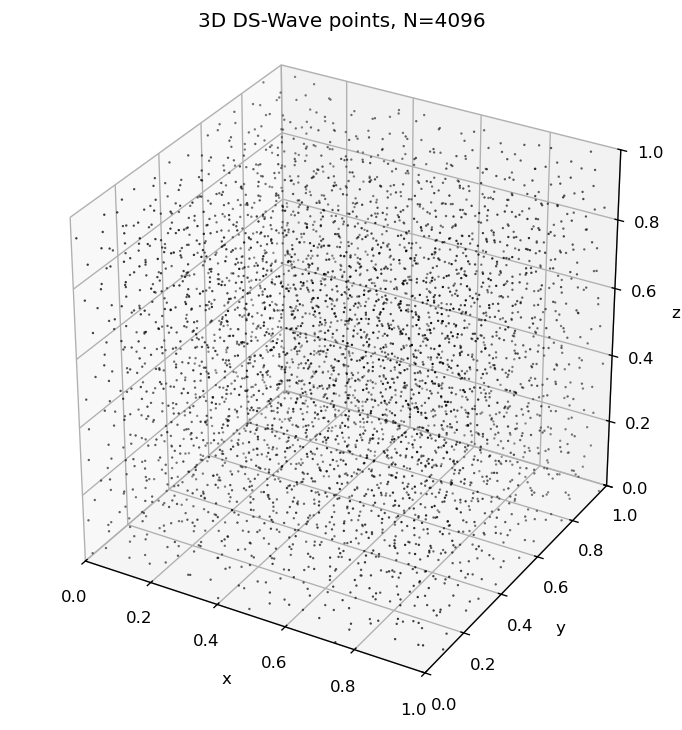

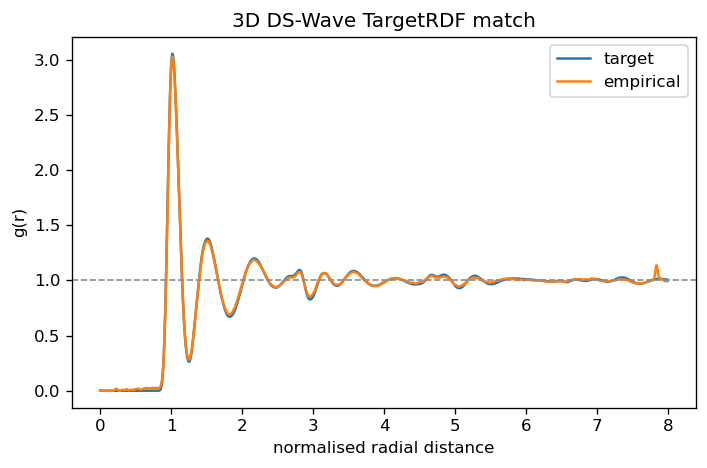

In [ ]:
# 3D DS-Wave point synthesis.
synthesis_3d = ds_wave_3d.synthesize_toroidal_points_3d(
	target_3d,
	n_points=n_points_3d,
	iterations=iterations_3d,
	seed=seed,
	device=device,
	step_scale=pcf_step_scale_3d,
	nbins=pcf_num_bins_3d,
	smoothing=pcf_smoothing_3d,
	chunk_size=pcf_chunk_size_3d,
	log_every=max(iterations_3d // 10, 1),
)
points_3d = synthesis_3d["points"]
print(f"3D points: {points_3d.shape}, device={synthesis_3d['device']}")
print("Energy history:")
for value in synthesis_3d["energy_history"]:
	print(value)

fig = plt.figure(figsize=(6, 6), dpi=120)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=2.0, c="black", linewidths=0)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"3D DS-Wave points, N={n_points_3d}")
try:
	ax.set_box_aspect((1, 1, 1))
except AttributeError:
	pass
fig.tight_layout()
fig.show()

fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
ax.plot(synthesis_3d["r_values"], synthesis_3d["target_rdf"], label="target")
ax.plot(synthesis_3d["r_values"], synthesis_3d["final_rdf"], label="empirical")
ax.axhline(1.0, color="0.55", linestyle="--", linewidth=1)
ax.set_xlabel("normalised radial distance")
ax.set_ylabel("g(r)")
ax.set_title("3D DS-Wave TargetRDF match")
ax.legend()
fig.tight_layout()
fig.show()


In [ ]:
if "points_3d" not in globals():
	print("Run the 3D point synthesis cell first.")
else:
	fig = go.Figure(
		data=[
			go.Scatter3d(
				x=points_3d[:, 0],
				y=points_3d[:, 1],
				z=points_3d[:, 2],
				mode="markers",
				marker=dict(
					size=2,
					color="black",
					opacity=0.75,
				),
			)
		]
	)

	fig.update_layout(
		title=f"3D DS-Wave points, N={n_points_3d}",
		scene=dict(
			xaxis=dict(range=[0, 1], title="x"),
			yaxis=dict(range=[0, 1], title="y"),
			zaxis=dict(range=[0, 1], title="z"),
			aspectmode="cube",
		),
		width=750,
		height=750,
	)

	fig.show()


C:\Users\ville\AppData\Local\Temp\ipykernel_105500\1669866663.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


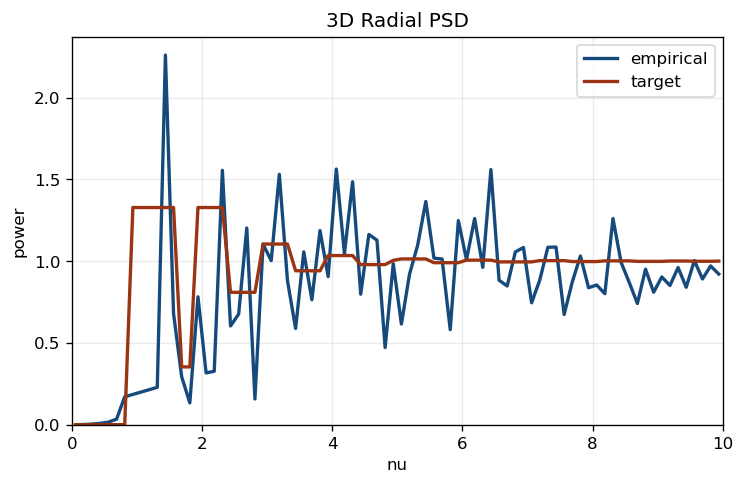

In [ ]:
# 3D radial PSD diagnostic
psd_num_bins_3d = 80
psd_mode_limit_3d = 12000

if "points_3d" not in globals():
	print("Run the 3D point synthesis cell first.")
else:
	fig = ds_wave_3d.plot_radial_psd_overlay_3d(
		points_3d,
		target_3d,
		num_bins=psd_num_bins_3d,
		max_freq=nu_max,
		mode_limit=psd_mode_limit_3d,
	)
	fig.show()


C:\Users\ville\AppData\Local\Temp\ipykernel_105500\2810252464.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


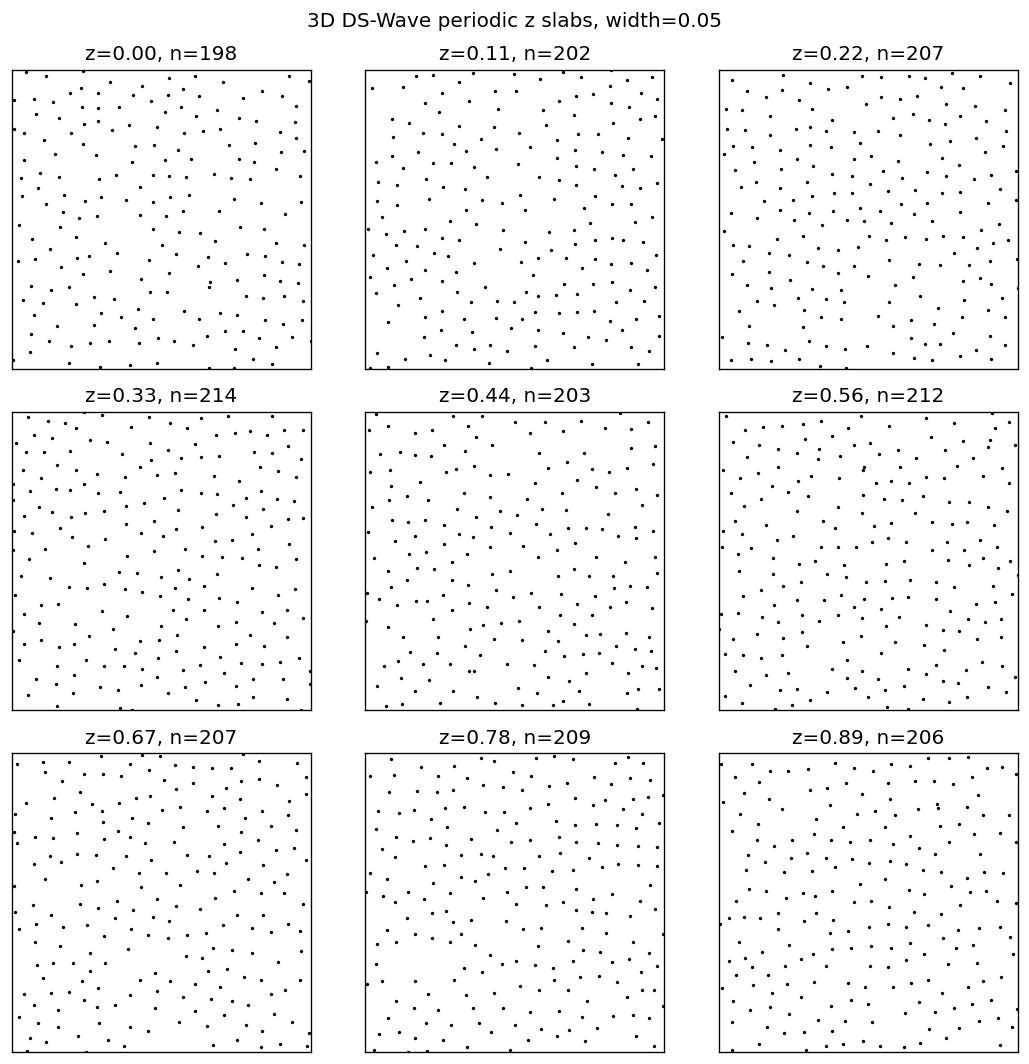

In [ ]:
# 3D slice visualization: several periodic z slabs
slice_width = 0.05
slice_z_values = np.linspace(0.0, 1.0, 9, endpoint=False)

if "points_3d" not in globals():
	print("Run the 3D point synthesis cell first.")
else:
	fig, axes = plt.subplots(3, 3, figsize=(9, 9), dpi=120)
	for ax, z0 in zip(axes.ravel(), slice_z_values):
		dz = np.abs(points_3d[:, 2] - z0)
		dz = np.minimum(dz, 1.0 - dz)
		slice_points = points_3d[dz < 0.5 * slice_width]

		ax.scatter(slice_points[:, 0], slice_points[:, 1], s=4, c="black", linewidths=0)
		ax.set_xlim(0, 1)
		ax.set_ylim(0, 1)
		ax.set_aspect("equal")
		ax.set_xticks([])
		ax.set_yticks([])
		ax.set_title(f"z={z0:.2f}, n={len(slice_points)}")

	fig.suptitle(f"3D DS-Wave periodic z slabs, width={slice_width}")
	fig.tight_layout()
	fig.show()


slice points: 206 / 4096


C:\Users\ville\AppData\Local\Temp\ipykernel_105500\475460914.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


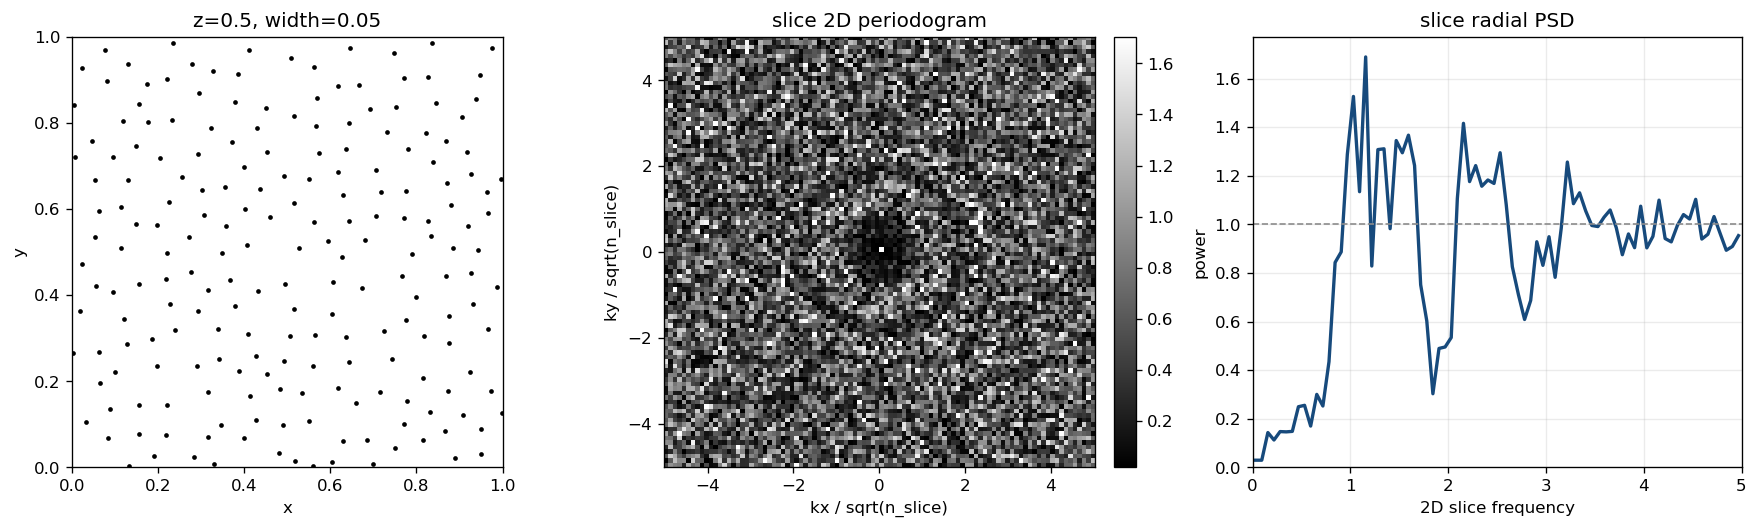

In [ ]:
if "points_3d" not in globals():
	print("Run the 3D point synthesis cell first.")
else:
	# Single 3D slice diagnostic with 2D periodogram and radial PSD
	slice_z = 0.5
	slice_width = 0.05
	slice_psd_grid_size = 96
	slice_num_bins = 80
	slice_max_freq = 5.0

	slice_dz = np.abs(points_3d[:, 2] - slice_z)
	slice_dz = np.minimum(slice_dz, 1.0 - slice_dz)
	slice_points = points_3d[slice_dz < 0.5 * slice_width][:, :2]
	print(f"slice points: {slice_points.shape[0]} / {points_3d.shape[0]}")

	fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=120)
	axes[0].scatter(slice_points[:, 0], slice_points[:, 1], s=8, c="black", linewidths=0)
	axes[0].set_xlim(0, 1)
	axes[0].set_ylim(0, 1)
	axes[0].set_aspect("equal")
	axes[0].set_title(f"z={slice_z}, width={slice_width}")
	axes[0].set_xlabel("x")
	axes[0].set_ylabel("y")

	if slice_points.shape[0] >= 2:
		power_2d, extent = ds_wave.compute_periodogram_2d(
			slice_points,
			grid_size=slice_psd_grid_size,
			max_freq=slice_max_freq,
		)
		display_power = power_2d.copy()
		display_power[display_power.shape[0] // 2, display_power.shape[1] // 2] = np.nan
		log_power = np.log1p(display_power)
		vmin, vmax = np.nanpercentile(log_power, [2.0, 99.0])
		image = axes[1].imshow(
			log_power,
			origin="lower",
			extent=extent,
			cmap="gray",
			vmin=vmin,
			vmax=vmax,
			interpolation="nearest",
		)
		axes[1].set_title("slice 2D periodogram")
		axes[1].set_xlabel("kx / sqrt(n_slice)")
		axes[1].set_ylabel("ky / sqrt(n_slice)")
		fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)

		freqs, radial = ds_wave.compute_radial_psd(
			slice_points,
			num_bins=slice_num_bins,
			max_freq=slice_max_freq,
			mode_limit=8192,
		)
		axes[2].plot(freqs, radial, color="#174a7c", linewidth=2.0)
		axes[2].axhline(1.0, color="0.55", linestyle="--", linewidth=1)
		axes[2].set_xlim(0.0, slice_max_freq)
		axes[2].set_ylim(bottom=0.0)
		axes[2].set_title("slice radial PSD")
		axes[2].set_xlabel("2D slice frequency")
		axes[2].set_ylabel("power")
		axes[2].grid(True, alpha=0.25)
	else:
		axes[1].set_axis_off()
		axes[2].set_axis_off()

	fig.tight_layout()
	fig.show()
